Entropy of the dataset: 0.881
S NO - Entropy: 3.322, Information Gain: 0.881
CGPA - Entropy: 1.522, Information Gain: 0.557
INTERACTIVE - Entropy: 0.971, Information Gain: 0.091
PRACTICE KNOWLEDGE - Entropy: 1.485, Information Gain: 0.245
COMMUNICATION SKILL - Entropy: 1.485, Information Gain: 0.520

Generated Decision Tree (ID3):
{'S NO': {np.int64(1): 'Y', np.int64(2): 'Y', np.int64(3): 'N', np.int64(4): 'N', np.int64(5): 'Y', np.int64(6): 'Y', np.int64(7): 'N', np.int64(8): 'Y', np.int64(9): 'Y', np.int64(10): 'Y'}}


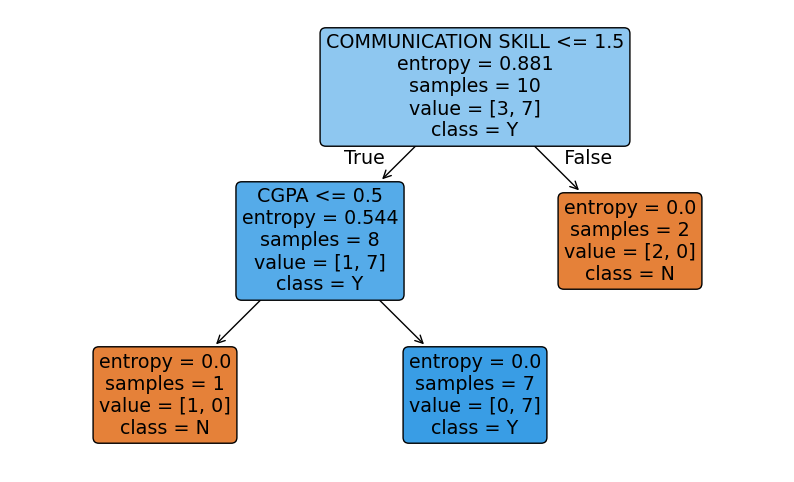


Sample Prediction (JOB OFFER): ['m']


In [21]:
import pandas as pd
import numpy as np
import math
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Load corrected CSV (tab-separated original)
df = pd.read_csv("studentmarks.csv")


# Target column is 'JOB OFFER'
target_column = 'JOB OFFER'

# Entropy calculation
def calculate_entropy(data, target_column):
    total_rows = len(data)
    target_values = data[target_column].unique()

    entropy = 0
    for value in target_values:
        value_count = len(data[data[target_column] == value])
        proportion = value_count / total_rows
        if proportion != 0:
            entropy -= proportion * math.log2(proportion)

    return entropy

# Calculate total entropy
entropy_outcome = calculate_entropy(df, target_column)
print(f"Entropy of the dataset: {entropy_outcome:.3f}")

# Information gain calculation
def calculate_information_gain(data, feature, target_column):
    unique_values = data[feature].unique()
    weighted_entropy = 0

    for value in unique_values:
        subset = data[data[feature] == value]
        proportion = len(subset) / len(data)
        weighted_entropy += proportion * calculate_entropy(subset, target_column)

    return entropy_outcome - weighted_entropy

# Display entropy & IG for each feature
for column in df.columns[:-1]:
    entropy = calculate_entropy(df, column)
    information_gain = calculate_information_gain(df, column, target_column)
    print(f"{column} - Entropy: {entropy:.3f}, Information Gain: {information_gain:.3f}")

# ID3 implementation for categorical data
def id3(data, target_column, features):
    if len(data[target_column].unique()) == 1:
        return data[target_column].iloc[0]

    if len(features) == 0:
        return data[target_column].mode().iloc[0]

    best_feature = max(features, key=lambda x: calculate_information_gain(data, x, target_column))
    tree = {best_feature: {}}
    features = [f for f in features if f != best_feature]

    for value in data[best_feature].unique():
        subset = data[data[best_feature] == value]
        if subset.empty:
            tree[best_feature][value] = data[target_column].mode().iloc[0]
        else:
            tree[best_feature][value] = id3(subset, target_column, features)

    return tree

# Build tree
features = list(df.columns[:-1])
tree = id3(df, target_column, features)
print("\nGenerated Decision Tree (ID3):")
print(tree)

# For visualization with sklearn, encode categorical variables
encoder = LabelEncoder()
df_encoded = df.copy()
for col in df_encoded.columns:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

X = df_encoded.drop(columns=[target_column])
y = df_encoded[target_column]

clf = DecisionTreeClassifier(criterion='entropy', max_depth=3)
clf.fit(X, y)

plt.figure(figsize=(10, 6))
plot_tree(clf, feature_names=list(X.columns), class_names=encoder.classes_, filled=True, rounded=True)
plt.show()

# Sample prediction
sample_input = pd.DataFrame([{
    "S NO": 11,
    "CGPA": ">=9",
    "INTERACTIVE": "Y",
    "PRACTICE KNOWLEDGE": "vg",
    "COMMUNICATION SKILL": "g"
}])

# Encode using same label encodings
for col in sample_input.columns:
    sample_input[col] = encoder.fit_transform(
        list(df[col].unique()) + list(sample_input[col])
    )[-1:]  # Get encoded value for the sample

pred = clf.predict(sample_input)
print("\nSample Prediction (JOB OFFER):", encoder.inverse_transform(pred))

In [22]:
df.head()

,S NO,CGPA,INTERACTIVE,PRACTICE KNOWLEDGE,COMMUNICATION SKILL,JOB OFFER
0,1,>=9,Y,vg,g,Y
1,2,>=8,N,g,m,Y
2,3,>=9,N,avg,p,N
3,4,<8,N,avg,g,N
4,5,>=8,Y,g,m,Y


In [23]:
df.tail()

,S NO,CGPA,INTERACTIVE,PRACTICE KNOWLEDGE,COMMUNICATION SKILL,JOB OFFER
5,6,>=9,Y,g,m,Y
6,7,<8,Y,g,p,N
7,8,>=9,N,vg,g,Y
8,9,>=8,Y,g,g,Y
9,10,>=8,Y,avg,g,Y


In [15]:
def calculate_entropy(data, target_column):
    total_rows = len(data)
    target_values = data[target_column].unique()

    entropy = 0
    for value in target_values:
        # Calculate the proportion of instances with the current value
        value_count = len(data[data[target_column] == value])
        proportion = value_count / total_rows
        entropy -= proportion * math.log2(proportion)

    return entropy

entropy_outcome = calculate_entropy(df, 'Outcome')
print(f&quot;Entropy of the dataset: {entropy_outcome}&quot;)

def calculate_entropy(data, target_column): # for each categorical variable
    total_rows = len(data)
    target_values = data[target_column].unique()

    entropy = 0
    for value in target_values:
        # Calculate the proportion of instances with the current value
        value_count = len(data[data[target_column] == value])
        proportion = value_count / total_rows
        entropy -= proportion * math.log2(proportion) if proportion != 0 else 0

    return entropy
  
def calculate_information_gain(data, feature, target_column):

    # Calculate weighted average entropy for the feature
    unique_values = data[feature].unique()
    weighted_entropy = 0

    for value in unique_values:
        subset = data[data[feature] == value]
        proportion = len(subset) / len(data)
        weighted_entropy += proportion * calculate_entropy(subset, target_column)

    # Calculate information gain
    information_gain = entropy_outcome - weighted_entropy

    return information_gain

for column in df.columns[:-1]:
    entropy = calculate_entropy(df, column)
    information_gain = calculate_information_gain(df, column, 'Outcome')
    print(f&quot;{column} - Entropy: {entropy:.3f}, Information Gain: {information_gain:.3f}&quot;)

# Feature selection for the first step in making decision tree
selected_feature = 'DiabetesPedigreeFunction'

# Create a decision tree
clf = DecisionTreeClassifier(criterion='entropy', max_depth=1)
X = df[[selected_feature]]
y = df['Outcome']
clf.fit(X, y)

plt.figure(figsize=(8, 6))
plot_tree(clf, feature_names=[selected_feature], class_names=['0', '1'], filled=True, rounded=True)
plt.show()

def id3(data, target_column, features):
    if len(data[target_column].unique()) == 1:
        return data[target_column].iloc[0]

 
    if len(features) == 0:
        return data[target_column].mode().iloc[0]

    best_feature = max(features, key=lambda x: calculate_information_gain(data, x, target_column))

    tree = {best_feature: {}}

    features = [f for f in features if f != best_feature]

    for value in data[best_feature].unique():
        subset = data[data[best_feature] == value]
        tree[best_feature][value] = id3(subset, target_column, features)

    return tree

SyntaxError: invalid decimal literal (4265653082.py, line 49)